<a href="https://colab.research.google.com/github/rahamasaleh1/MedicineVerificationSystem/blob/main/BankMarketingAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Rahama Saleh
# Bank Marketing Campaign Analysis: Who Subscribes and How to Target Them

Tools: Python, pandas, matplotlib, seaborn, scikit learn

## The business question

A Portuguese retail bank ran a telephone marketing campaign to sell term deposits. Most calls did not convert, which means agent time was spent on customers who were never going to say yes.

This analysis answers three questions for the marketing team:

1. Who is most likely to subscribe?
2. When and how should the bank contact them?
3. How much more efficient could the next campaign be if calls were prioritised using the data?

## Approach

1. Audit data quality and document every cleaning decision
2. Establish the baseline conversion rate
3. Break conversion down by customer profile, timing and campaign history
4. Build an interpretable model that ranks customers by likelihood to subscribe
5. Translate the findings into recommendations

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

sns.set_theme(style="whitegrid")
PRIMARY = "#2E5A88"
ACCENT = "#E07A5F"
pd.set_option("display.float_format", "{:.2f}".format)

## 2. Load the data

In Google Colab, upload `bank_dataset rs.xlsx` using the Files panel on the left before running this cell.

In [2]:
raw = pd.read_excel("bank_dataset rs.xlsx")
print(f"Rows: {raw.shape[0]:,}   Columns: {raw.shape[1]}")
raw.head()

Rows: 41,188   Columns: 16


,age,job,marital,education,default,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome,y
0,56.00,housemaid,married,basic.4y,no,no,no,telephone,mon,may,261.00,1,999.00,0,nonexistent,no
1,57.00,services,married,high.school,unknown,no,no,telephone,mon,may,149.00,1,999.00,0,nonexistent,no
2,37.00,services,married,high.school,no,yes,no,telephone,mon,may,226.00,1,999.00,0,nonexistent,no
3,40.00,admin.,married,basic.6y,no,no,no,telephone,mon,may,151.00,1,999.00,0,nonexistent,no
4,56.00,services,married,high.school,no,no,yes,telephone,mon,may,307.00,1,999.00,0,nonexistent,no


## 3. Data quality audit

Before any analysis, I check four things: data types, missing values, duplicate records and placeholder values that look valid but carry hidden meaning.

In [3]:
audit = pd.DataFrame({
    "dtype": raw.dtypes.astype(str),
    "missing": raw.isnull().sum(),
    "missing_%": (raw.isnull().mean() * 100).round(3),
    "unique_values": raw.nunique(),
})
audit

,dtype,missing,missing_%,unique_values
age,float64,11,0.03,81
job,object,17,0.04,12
marital,object,0,0.00,6
education,object,0,0.00,9
default,object,20,0.05,3
housing,object,0,0.00,4
loan,object,0,0.00,4
contact,object,10,0.02,3
day_of_week,object,0,0.00,7
month,object,0,0.00,11


In [4]:
print(f"Exact duplicate rows: {raw.duplicated().sum():,}")

# 'unknown' is a text placeholder, so isnull() does not catch it
unknown_counts = (raw.select_dtypes(include=["object", "string"]) == "unknown").sum()
print("\n'unknown' values per column:")
print(unknown_counts[unknown_counts > 0])

# pdays = 999 means the customer was never contacted before
print(f"\npdays = 999 (never previously contacted): {(raw['pdays'] == 999).mean():.1%} of rows")

Exact duplicate rows: 13

'unknown' values per column:
job           330
marital        76
education    1731
default      8585
housing       990
loan          990
dtype: int64

pdays = 999 (never previously contacted): 96.3% of rows


**Audit findings**

* Missing values affect only a handful of rows in each column, well under 0.1% of the data, so removing those rows will not bias the results.
* A small number of exact duplicate rows exist and are removed.
* `unknown` appears in several categorical columns. These are kept as their own category because "unknown" can itself carry signal (for example, customers who decline to disclose credit default status).
* `pdays` uses **999 as a code for "never contacted"**. Left as a number it would distort any average or chart, so it is converted into a clear yes/no flag.
* `duration` (call length) is only known **after** the call ends. It cannot be used to decide who to call, so it is excluded from the predictive model (see Section 8).

## 4. Cleaning and feature preparation

In [5]:
df = raw.copy()
start = len(df)

df = df.dropna()
after_na = len(df)
df = df.drop_duplicates()
after_dupes = len(df)

# Consistent types
df["age"] = df["age"].astype(int)
df["subscribed"] = (df["y"].str.strip().str.lower() == "yes").astype(int)

# Replace the 999 placeholder with a meaningful flag
df["previously_contacted"] = np.where(df["pdays"] == 999, "no", "yes")

# Business friendly age bands
df["age_band"] = pd.cut(df["age"], bins=[16, 24, 34, 44, 54, 64, 100],
                        labels=["17 to 24", "25 to 34", "35 to 44", "45 to 54", "55 to 64", "65+"])

# Ordered months and days for readable charts
month_order = ["mar", "apr", "may", "jun", "jul", "aug", "sep", "oct", "nov", "dec"]
day_order = ["mon", "tue", "wed", "thu", "fri"]

print(f"Starting rows:            {start:,}")
print(f"Removed (missing values): {start - after_na:,}")
print(f"Removed (duplicates):     {after_na - after_dupes:,}")
print(f"Final clean rows:         {len(df):,}  ({len(df) / start:.1%} of the original data retained)")

Starting rows:            41,188
Removed (missing values): 84
Removed (duplicates):     13
Final clean rows:         41,091  (99.8% of the original data retained)


## 5. The baseline: how well did the campaign convert?

In [6]:
BASELINE = df["subscribed"].mean()
print(f"Customers contacted: {len(df):,}")
print(f"Customers subscribed: {df['subscribed'].sum():,}")
print(f"Overall conversion rate: {BASELINE:.1%}")
print(f"Calls needed per subscription: {1 / BASELINE:.1f}")

Customers contacted: 41,091
Customers subscribed: 4,616
Overall conversion rate: 11.2%
Calls needed per subscription: 8.9


Roughly **nine in ten calls did not convert**. Every segment below is compared against this baseline: anything above the dashed line converts better than average, anything below converts worse.

In [7]:
def conversion_chart(column, title, order=None, min_size=100, ax=None, horizontal=False):
    """Plot conversion rate by segment against the campaign baseline."""
    summary = (df.groupby(column, observed=True)["subscribed"]
                 .agg(customers="count", conversion="mean")
                 .query("customers >= @min_size"))
    if order is not None:
        summary = summary.reindex([o for o in order if o in summary.index])
    else:
        summary = summary.sort_values("conversion", ascending=horizontal)

    if ax is None:
        _, ax = plt.subplots(figsize=(10, 5))
    colours = [ACCENT if v > BASELINE else PRIMARY for v in summary["conversion"]]
    labels = summary.index.astype(str)
    if horizontal:
        ax.barh(labels, summary["conversion"], color=colours)
        ax.axvline(BASELINE, ls="--", c="grey", label=f"Baseline {BASELINE:.1%}")
        ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    else:
        ax.bar(labels, summary["conversion"], color=colours)
        ax.axhline(BASELINE, ls="--", c="grey", label=f"Baseline {BASELINE:.1%}")
        ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel(""); ax.set_ylabel("")
    ax.legend(loc="best")
    return summary

## 6. Who subscribes? Customer profile

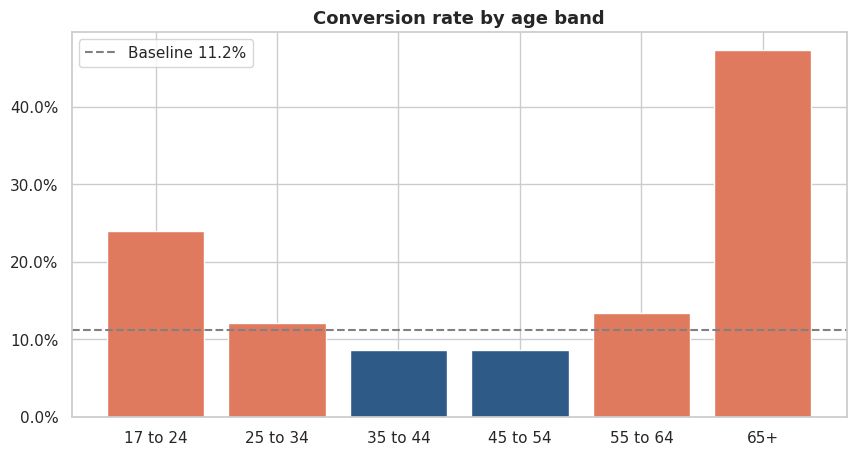

,customers,conversion
age_band,,
17 to 24,1058,0.24
25 to 34,13664,0.12
35 to 44,13470,0.09
45 to 54,8674,0.09
55 to 64,3562,0.13
65+,660,0.47


In [8]:
age_summary = conversion_chart("age_band", "Conversion rate by age band",
                               order=["17 to 24", "25 to 34", "35 to 44", "45 to 54", "55 to 64", "65+"])
plt.show()
age_summary

**Insight:** Conversion follows a clear **U shape**. The youngest and oldest customers convert far above the baseline, while the middle age bands, which make up most of the call list, convert below it. The campaign spent most of its effort on the least responsive age groups.

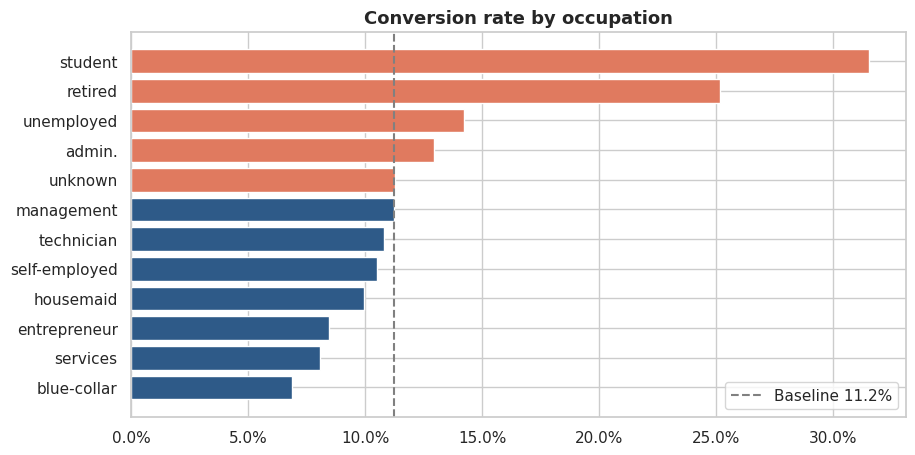

,customers,conversion
job,,
student,866,0.32
retired,1714,0.25
unemployed,1013,0.14
admin.,10406,0.13
unknown,328,0.11
management,2911,0.11
technician,6729,0.11
self-employed,1420,0.10
housemaid,1057,0.10


In [9]:
job_summary = conversion_chart("job", "Conversion rate by occupation", horizontal=True)
plt.show()
job_summary.sort_values("conversion", ascending=False)

**Insight:** Students and retired customers are the standout segments, consistent with the age pattern above. Blue collar and services workers convert least, yet represent a large share of calls.

## 7. When and how to call? Timing and campaign strategy

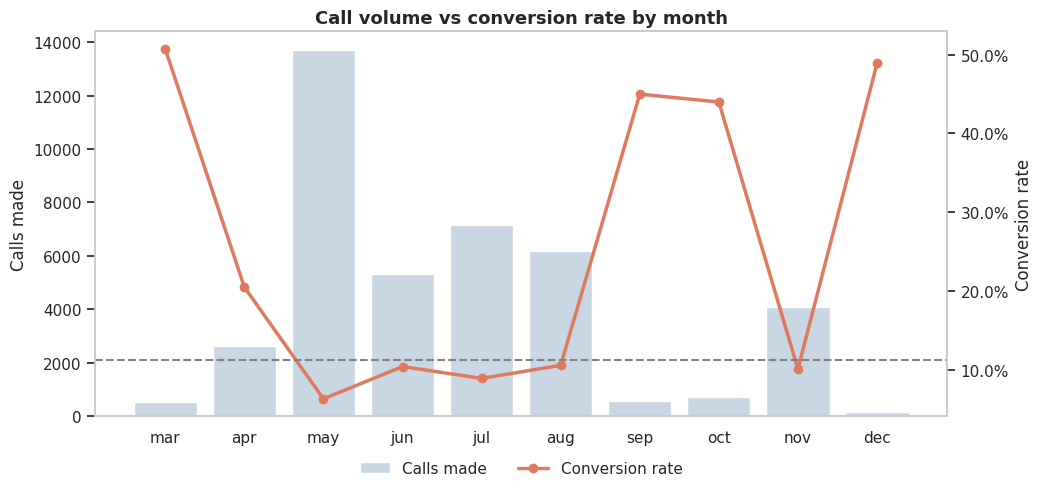

,calls,conversion
month,,
mar,544,0.51
apr,2617,0.21
may,13716,0.06
jun,5306,0.10
jul,7157,0.09
aug,6171,0.11
sep,569,0.45
oct,716,0.44
nov,4096,0.10


In [10]:
fig, ax1 = plt.subplots(figsize=(11, 5))
monthly = (df.groupby("month")["subscribed"].agg(calls="count", conversion="mean")
             .reindex([m for m in month_order if m in df["month"].unique()]))

ax1.bar(monthly.index, monthly["calls"], color="#C9D6E3", label="Calls made")
ax1.set_ylabel("Calls made")
ax2 = ax1.twinx()
ax2.plot(monthly.index, monthly["conversion"], color=ACCENT, marker="o", lw=2.5, label="Conversion rate")
ax2.axhline(BASELINE, ls="--", c="grey")
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax2.set_ylabel("Conversion rate")
ax2.grid(False)
ax1.set_title("Call volume vs conversion rate by month", fontsize=13, fontweight="bold")
ax1.grid(False)
h1, l1 = ax1.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="upper center", ncol=2, bbox_to_anchor=(0.5, -0.08), frameon=False)
plt.show()
monthly

**Insight:** Call volume and conversion move in **opposite directions**. May had by far the most calls and one of the weakest conversion rates, while March, September, October and December converted several times above the baseline on a fraction of the volume. Rebalancing effort towards the high converting months is a low cost win.

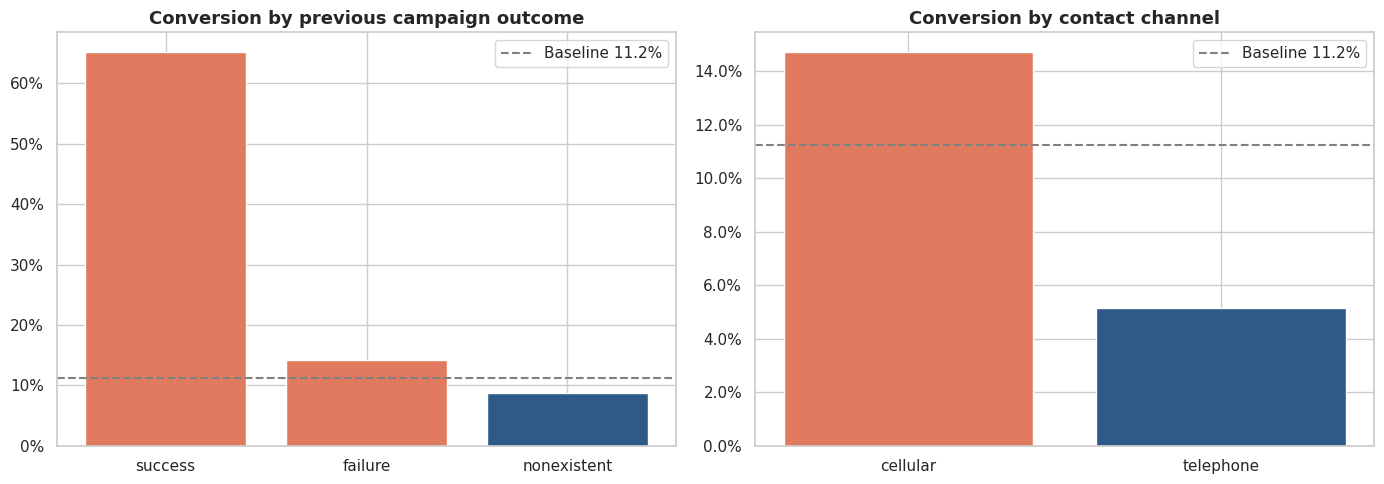

,customers,conversion
poutcome,,
success,1370,0.65
failure,4239,0.14
nonexistent,35459,0.09


,customers,conversion
contact,,
cellular,26082,0.15
telephone,14999,0.05


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
poutcome_summary = conversion_chart("poutcome", "Conversion by previous campaign outcome", ax=axes[0])
contact_summary = conversion_chart("contact", "Conversion by contact channel", ax=axes[1])
plt.tight_layout(); plt.show()
display(poutcome_summary, contact_summary)

**Insight:** Past behaviour is the single strongest signal in the data. Customers who said yes to a **previous campaign** convert at many times the baseline rate. Customers reached on a **mobile** also convert well above those reached on a landline.

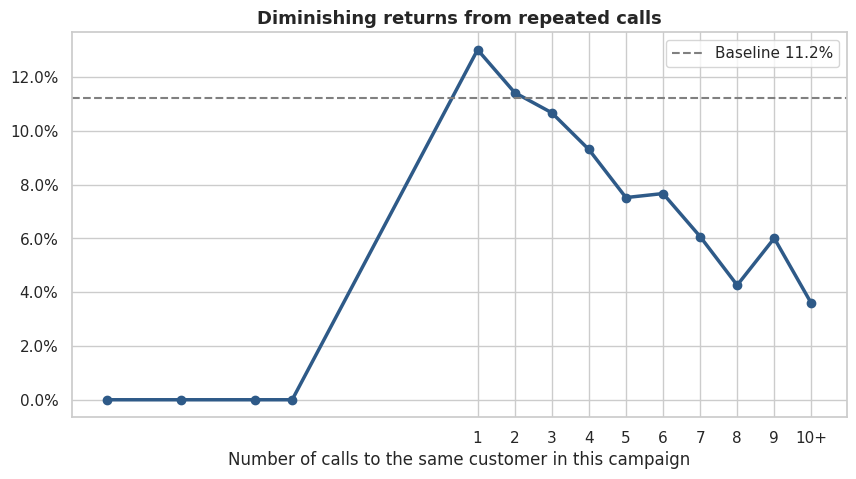

,customers,conversion
calls_this_campaign,,
-9,1,0.00
-7,1,0.00
-5,2,0.00
-4,1,0.00
1,17593,0.13
2,10549,0.11
3,5331,0.11
4,2643,0.09
5,1596,0.08


In [12]:
df["calls_this_campaign"] = df["campaign"].clip(upper=10)
calls = df.groupby("calls_this_campaign")["subscribed"].agg(customers="count", conversion="mean")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(calls.index, calls["conversion"], marker="o", color=PRIMARY, lw=2.5)
ax.axhline(BASELINE, ls="--", c="grey", label=f"Baseline {BASELINE:.1%}")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_xticks(range(1, 11))
ax.set_xticklabels([str(i) for i in range(1, 10)] + ["10+"])
ax.set_xlabel("Number of calls to the same customer in this campaign")
ax.set_title("Diminishing returns from repeated calls", fontsize=13, fontweight="bold")
ax.legend(); plt.show()
calls

**Insight:** Conversion is highest on the first call and falls steadily with each repeat attempt. After a few calls, further attempts cost agent time while adding very little. A **cap on repeat calls** would free capacity for new, higher potential customers.

## 8. Why call duration is excluded

/tmp/ipykernel_5552/4226644535.py:2: UserWarning: 
The palette list has fewer values (2) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.boxplot(data=df, x="y", y="duration", hue="y", palette=[PRIMARY, ACCENT],


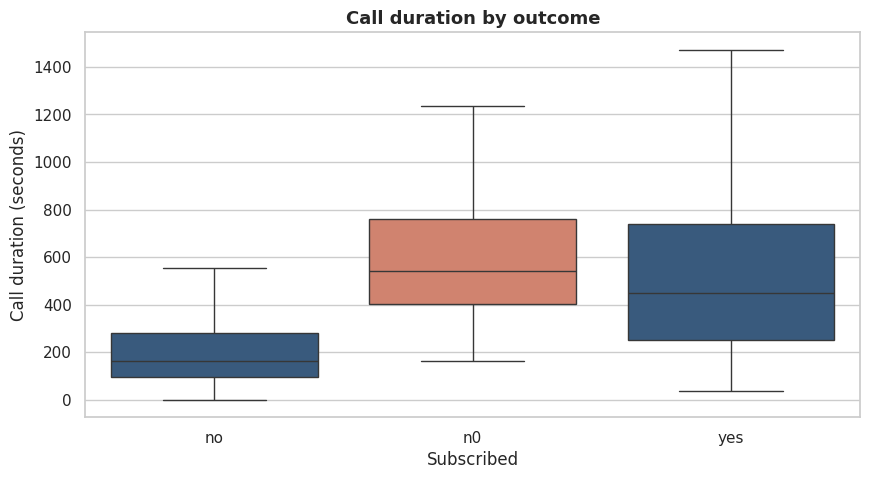

y
n0    543.00
no    164.00
yes   449.00
Name: median duration (s), dtype: float64


In [13]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="y", y="duration", hue="y", palette=[PRIMARY, ACCENT],
            showfliers=False, legend=False)
plt.title("Call duration by outcome", fontsize=13, fontweight="bold")
plt.xlabel("Subscribed"); plt.ylabel("Call duration (seconds)")
plt.show()
print(df.groupby("y")["duration"].median().rename("median duration (s)"))

Successful calls are much longer, but this is a **consequence** of the outcome rather than a cause: a customer who is subscribing stays on the phone to complete the process. Since duration is unknown until the call ends, including it in a model would produce impressive but unusable accuracy. This is a common data leakage trap, and excluding it keeps the model honest and deployable.

## 9. Predictive model: ranking customers by likelihood to subscribe

I use **logistic regression** because it is transparent: every coefficient can be explained to a non technical stakeholder. The model uses only information available **before** a call is made.

In [14]:
features_cat = ["job", "marital", "education", "default", "housing", "loan",
                "contact", "month", "day_of_week", "poutcome", "previously_contacted"]
features_num = ["age", "campaign", "previous"]

X = df[features_cat + features_num]
y = df["subscribed"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25,
                                                    stratify=y, random_state=42)

model = Pipeline([
    ("prep", ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), features_cat),
        ("num", StandardScaler(), features_num),
    ])),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced")),
])
model.fit(X_train, y_train)

scores = model.predict_proba(X_test)[:, 1]
print(f"ROC AUC on unseen test data: {roc_auc_score(y_test, scores):.3f}")
print("(0.5 = random guessing, 1.0 = perfect ranking)")

ROC AUC on unseen test data: 0.773
(0.5 = random guessing, 1.0 = perfect ranking)


### Business impact: the lift curve

Accuracy scores mean little to a marketing team. The question that matters is: **if we only call the customers the model ranks highest, what share of subscribers do we still reach?**

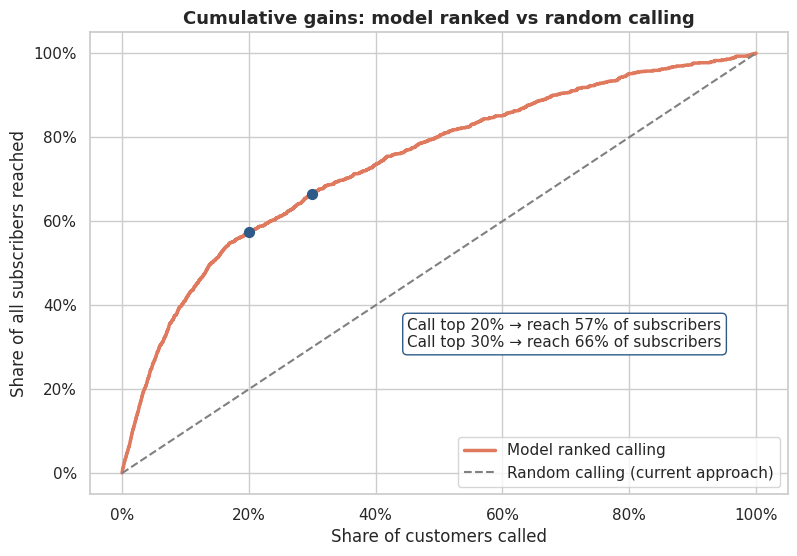

Calling the top 20% reaches 57% of subscribers
Conversion in the top 20%: 32.2% vs 11.2% overall (2.9x lift)


In [15]:
ranked = pd.DataFrame({"score": scores, "actual": y_test.values}).sort_values("score", ascending=False)
ranked["pct_called"] = np.arange(1, len(ranked) + 1) / len(ranked)
ranked["pct_subscribers_found"] = ranked["actual"].cumsum() / ranked["actual"].sum()

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(ranked["pct_called"], ranked["pct_subscribers_found"], color=ACCENT, lw=2.5, label="Model ranked calling")
ax.plot([0, 1], [0, 1], ls="--", c="grey", label="Random calling (current approach)")
notes = []
for cut in [0.2, 0.3]:
    found = ranked.loc[ranked["pct_called"] <= cut, "pct_subscribers_found"].iloc[-1]
    ax.scatter(cut, found, color=PRIMARY, zorder=5, s=50)
    notes.append(f"Call top {cut:.0%} → reach {found:.0%} of subscribers")
ax.text(0.45, 0.30, "\n".join(notes), fontsize=11,
        bbox=dict(boxstyle="round", fc="white", ec=PRIMARY))
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_xlabel("Share of customers called"); ax.set_ylabel("Share of all subscribers reached")
ax.set_title("Cumulative gains: model ranked vs random calling", fontsize=13, fontweight="bold")
ax.legend(loc="lower right"); plt.show()

top20 = ranked[ranked["pct_called"] <= 0.2]
lift = top20["actual"].mean() / ranked["actual"].mean()
print(f"Calling the top 20% reaches {top20['actual'].sum() / ranked['actual'].sum():.0%} of subscribers")
print(f"Conversion in the top 20%: {top20['actual'].mean():.1%} vs {ranked['actual'].mean():.1%} overall ({lift:.1f}x lift)")

### What drives the model?

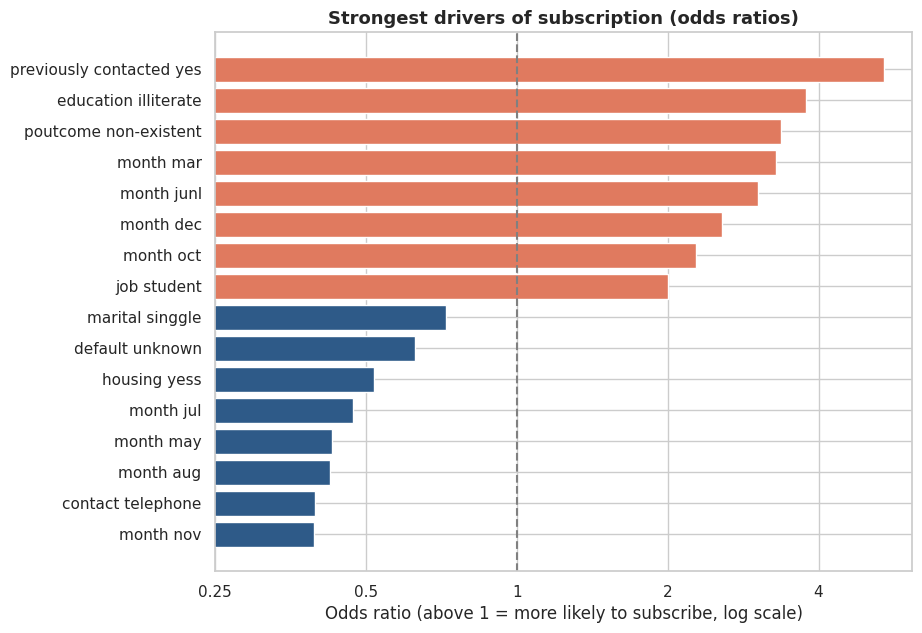

In [16]:
names = model.named_steps["prep"].get_feature_names_out()
names = [n.split("__", 1)[1].replace("_", " ", n.count("_") - 1).replace("_", ": ") for n in names]
odds = pd.Series(np.exp(model.named_steps["clf"].coef_[0]), index=names)

top = pd.concat([odds.nlargest(8), odds.nsmallest(8)]).sort_values()
plt.figure(figsize=(9, 7))
plt.barh(top.index, top.values, color=[ACCENT if v > 1 else PRIMARY for v in top.values])
plt.axvline(1, c="grey", ls="--")
plt.xscale("log")
plt.xticks([0.25, 0.5, 1, 2, 4], ["0.25", "0.5", "1", "2", "4"])
plt.title("Strongest drivers of subscription (odds ratios)", fontsize=13, fontweight="bold")
plt.xlabel("Odds ratio (above 1 = more likely to subscribe, log scale)")
plt.show()

Odds ratios above 1 increase the likelihood of subscribing; below 1 reduce it. Each category is compared with a reference group: months against April, occupations against admin, contact channel against mobile and previous outcome against a previous failure. The model independently confirms the patterns from the exploratory analysis: previous campaign success, mobile contact and timing are the strongest levers.

## 10. Recommendations for the marketing team

In [17]:
best_months = monthly.query("conversion > @BASELINE * 2").index.str.title().tolist()
print("KEY FIGURES")
print(f"  Baseline conversion:              {BASELINE:.1%}")
print(f"  Previous campaign success:        {poutcome_summary.loc['success', 'conversion']:.1%}")
print(f"  Mobile vs landline:               {contact_summary.loc['cellular', 'conversion']:.1%} vs {contact_summary.loc['telephone', 'conversion']:.1%}")
print(f"  May (busiest month):              {monthly.loc['may', 'conversion']:.1%} on {monthly.loc['may', 'calls']:,} calls")
print(f"  Months converting 2x baseline:    {', '.join(best_months)}")
print(f"  Top 20% model ranked conversion:  {top20['actual'].mean():.1%} ({lift:.1f}x lift)")

KEY FIGURES
  Baseline conversion:              11.2%
  Previous campaign success:        65.2%
  Mobile vs landline:               14.7% vs 5.2%
  May (busiest month):              6.4% on 13,716 calls
  Months converting 2x baseline:    Mar, Sep, Oct, Dec
  Top 20% model ranked conversion:  32.2% (2.9x lift)


1. **Prioritise past converters.** Customers who subscribed in a previous campaign are the most valuable audience in the data. They should be called first in every campaign.
2. **Rank the call list with the model.** Calling the highest scoring customers first reaches a large share of all subscribers for a fraction of the calls, freeing agent time for other work.
3. **Target the underserved segments.** Students and retirees convert well above the baseline but make up a small share of calls. Tailored messaging for these groups is a clear growth opportunity.
4. **Rebalance the calendar.** Shift volume away from saturated months such as May and towards the months where conversion is several times higher.
5. **Default to mobile.** Mobile contact converts substantially better than landline.
6. **Cap repeat calls.** Conversion falls with every repeat attempt, so limiting attempts per customer protects both agent capacity and customer goodwill.

## 11. Limitations and next steps

* The data covers a single bank and period, so seasonal patterns should be validated against a newer campaign before being applied.
* The model ranks likelihood; it does not prove cause and effect. An A/B test comparing model ranked calling with the current approach would confirm the real world uplift.
* Next steps: add economic context variables, test tree based models against the logistic baseline and present the findings in an interactive Power BI or Tableau dashboard.